In [1]:
import numpy as np
import matplotlib.pyplot as plt
import osmnx as ox
ox.settings.use_cache = False
import pandas as pd
import geopandas as gpd
from sklearn.preprocessing import StandardScaler
import networkx as nx
from sklearn.neighbors import kneighbors_graph
import contextily as ctx # For adding a background map

# Graph Convolutional Network - Chicago

Graph nodes (intersections) 2 km radius around center point (average longitude and latitude)

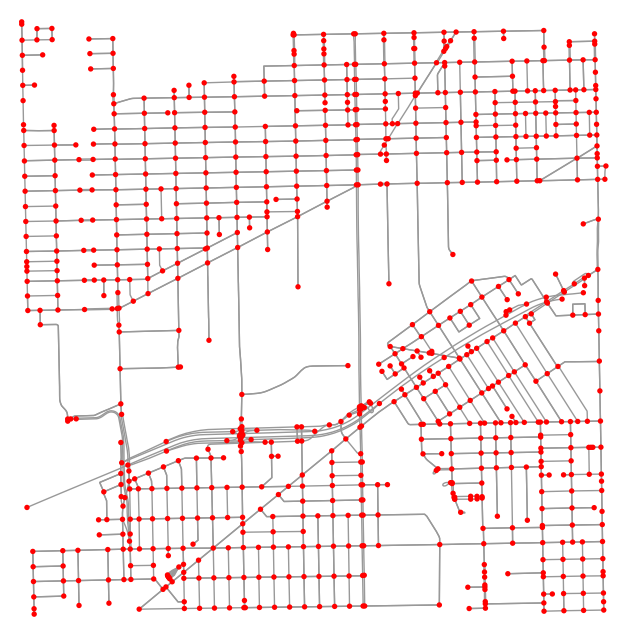

In [2]:
point = (41.8443, -87.6699)
G = ox.graph_from_point(point, dist=2000, network_type='drive')
fig, ax = ox.plot_graph(G, node_color='r', edge_color='#999999', bgcolor='w')

Nodes dataset describing crime location (x,y) and type of node (highway, traffic signal, junction, etc)

In [3]:
nodes = ox.graph_to_gdfs(G, edges=False)
nodes.head(5)

,y,x,street_count,highway,ref,junction,geometry
osmid,,,,,,,
25779213,41.845539,-87.650673,3,NaN,NaN,NaN,POINT (-87.65067 41.84554)
25779221,41.837422,-87.669478,3,motorway_junction,290,NaN,POINT (-87.66948 41.83742)
26098045,41.839102,-87.664226,3,NaN,NaN,NaN,POINT (-87.66423 41.8391)
27729276,41.845805,-87.647660,3,NaN,NaN,NaN,POINT (-87.64766 41.84581)
256180881,41.839215,-87.663035,3,NaN,NaN,NaN,POINT (-87.66303 41.83921)


Create dataframe of crime statistics

In [4]:
# Import csv of crimeData from github
df = pd.read_csv("crimes_2018.csv")
# Drop irrelevant columns
df = df[['Longitude', 'Latitude', 'Primary Type']]
# Remove missing values
df = df.dropna()

# Turn data frame into GeoDataFrame for manipulation
gdf_crime = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df.Longitude, df.Latitude), crs="EPSG:4326")
gdf_crime.head(5)

,Longitude,Latitude,Primary Type,geometry
0,-87.639324,41.903776,THEFT,POINT (-87.63932 41.90378)
1,-87.627508,41.898333,CRIM SEXUAL ASSAULT,POINT (-87.62751 41.89833)
2,-87.753029,41.891539,BATTERY,POINT (-87.75303 41.89154)
20,-87.757629,41.883604,HOMICIDE,POINT (-87.75763 41.8836)
23,-87.656756,41.988119,DECEPTIVE PRACTICE,POINT (-87.65676 41.98812)


Link points of interest to nearest node on graph using sjoin_nearest

Relating crime dataset to type of location at node

Count points of interest by category for each node

In [5]:
nodes_with_pois = gpd.sjoin_nearest(nodes, gdf_crime, how="left", distance_col="dist")

poi_counts = nodes_with_pois.groupby([nodes_with_pois.index, 'Primary Type']).size().unstack(fill_value=0)
poi_counts.head(5)

/usr/local/lib/python3.9/site-packages/geopandas/array.py:403: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


Primary Type,ASSAULT,BATTERY,BURGLARY,CONCEALED CARRY LICENSE VIOLATION,CRIM SEXUAL ASSAULT,CRIMINAL DAMAGE,CRIMINAL TRESPASS,DECEPTIVE PRACTICE,HOMICIDE,INTERFERENCE WITH PUBLIC OFFICER,LIQUOR LAW VIOLATION,MOTOR VEHICLE THEFT,NARCOTICS,OFFENSE INVOLVING CHILDREN,OTHER OFFENSE,PUBLIC PEACE VIOLATION,ROBBERY,SEX OFFENSE,THEFT,WEAPONS VIOLATION
osmid,,,,,,,,,,,,,,,,,,,,
25779213,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
25779221,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
26098045,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
27729276,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
256180881,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Aggregate and build final feature matrix X

In [6]:
nodes_with_crime = gpd.sjoin_nearest(nodes, gdf_crime, how="left")
crime_counts = nodes_with_crime.groupby(nodes_with_crime.index).size()

# Merge the crime counts and POI categories
X_df = pd.merge(poi_counts, crime_counts.to_frame('crime_count'), left_index=True, right_index=True, how='right').fillna(0)
X_df.head(5)

/usr/local/lib/python3.9/site-packages/geopandas/array.py:403: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


,ASSAULT,BATTERY,BURGLARY,CONCEALED CARRY LICENSE VIOLATION,CRIM SEXUAL ASSAULT,CRIMINAL DAMAGE,CRIMINAL TRESPASS,DECEPTIVE PRACTICE,HOMICIDE,INTERFERENCE WITH PUBLIC OFFICER,...,MOTOR VEHICLE THEFT,NARCOTICS,OFFENSE INVOLVING CHILDREN,OTHER OFFENSE,PUBLIC PEACE VIOLATION,ROBBERY,SEX OFFENSE,THEFT,WEAPONS VIOLATION,crime_count
osmid,,,,,,,,,,,,,,,,,,,,,
25779213,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
25779221,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
26098045,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
27729276,0,0,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
256180881,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


Turn points into Z-scores to get standardized version of matrix;

Turn into data frame

In [7]:
# StandardScaler() turns points into Z-scores
scaler = StandardScaler()
X_matrix = scaler.fit_transform(X_df)
# Numbers represent "hot spots" of crime for each node
X_matrix_df = pd.DataFrame(X_matrix)
X_matrix_df.columns = X_df.columns

Analyzing output: For each node how prone to certain crime is it than surrounding nodes

In [8]:
X_matrix_df.head(5)

,ASSAULT,BATTERY,BURGLARY,CONCEALED CARRY LICENSE VIOLATION,CRIM SEXUAL ASSAULT,CRIMINAL DAMAGE,CRIMINAL TRESPASS,DECEPTIVE PRACTICE,HOMICIDE,INTERFERENCE WITH PUBLIC OFFICER,...,MOTOR VEHICLE THEFT,NARCOTICS,OFFENSE INVOLVING CHILDREN,OTHER OFFENSE,PUBLIC PEACE VIOLATION,ROBBERY,SEX OFFENSE,THEFT,WEAPONS VIOLATION,crime_count
0,-0.359529,-0.477318,-0.290728,-0.077568,-0.103702,1.111086,-0.189999,-0.241557,-0.034606,-0.04897,...,-0.296999,-0.209864,-0.11003,-0.265037,-0.11003,-0.229993,-0.10432,-0.376797,-0.196238,-0.361817
1,-0.359529,-0.477318,-0.290728,-0.077568,-0.103702,-0.414149,-0.189999,-0.241557,-0.034606,-0.04897,...,-0.296999,3.604189,-0.11003,-0.265037,-0.11003,-0.229993,-0.10432,-0.376797,-0.196238,-0.361817
2,-0.359529,-0.477318,-0.290728,-0.077568,-0.103702,1.111086,-0.189999,-0.241557,-0.034606,-0.04897,...,-0.296999,-0.209864,-0.11003,-0.265037,-0.11003,-0.229993,-0.10432,-0.376797,-0.196238,-0.361817
3,-0.359529,-0.477318,6.022213,-0.077568,-0.103702,-0.414149,-0.189999,-0.241557,-0.034606,-0.04897,...,-0.296999,-0.209864,-0.11003,-0.265037,-0.11003,-0.229993,-0.10432,-0.376797,-0.196238,0.125267
4,2.124488,-0.477318,-0.290728,-0.077568,-0.103702,-0.414149,-0.189999,-0.241557,-0.034606,-0.04897,...,-0.296999,-0.209864,-0.11003,-0.265037,-0.11003,-0.229993,-0.10432,-0.376797,-0.196238,-0.361817


Plotting

/usr/local/lib/python3.9/site-packages/geopandas/array.py:403: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


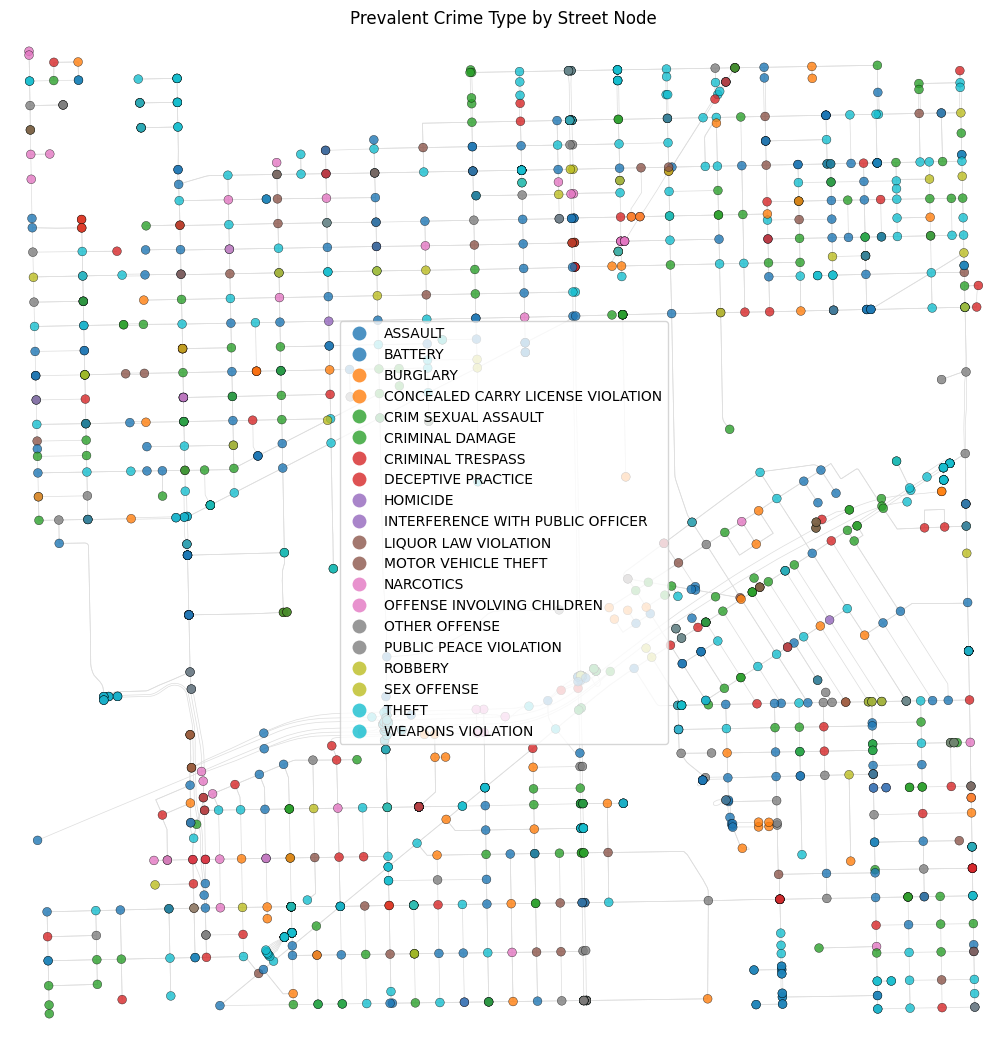

In [9]:
crime_columns = X_matrix_df.columns.tolist()
# Checking
existing_crime_cols = [col for col in crime_columns if col in X_matrix_df.columns]
# Filter out ones with no crime
nodes_with_crime_mask = X_matrix_df[existing_crime_cols].sum(axis=1) > 0
X_matrix_filtered = X_matrix_df[nodes_with_crime_mask].copy()

X_matrix_filtered['Prevalent_Crime'] = X_matrix_filtered[existing_crime_cols].idxmax(axis=1)

nodes_gdf = ox.graph_to_gdfs(G, edges=False)
nodes_visual = gpd.sjoin_nearest(nodes_gdf, gdf_crime, how="inner", distance_col="dist")

fig, ax = plt.subplots(figsize=(13, 13))
ox.plot_graph(G, ax=ax, node_size=0, edge_color='#dddddd', edge_linewidth=0.5, show=False, close=False)
# Plot the color-coded nodes
nodes_visual.plot(column='Primary Type', 
                    cmap='tab10', # A qualitative colormap for categories
                    markersize=40, 
                    legend=True, 
                    ax=ax, 
                    alpha=0.8, 
                    edgecolor='k', linewidth=0.3)

ax.set_title("Prevalent Crime Type by Street Node")
ax.axis('off')
plt.show()

# Graph Convolutional Network - Vancouver

Graph nodes (intersections) 2 km radius around center point (average longitude and latitude)

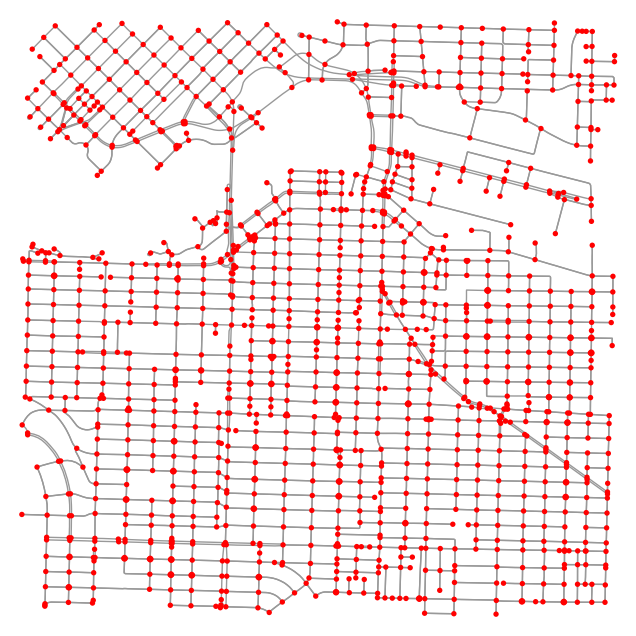

In [10]:
point = (49.2627,-123.1068)
G = ox.graph_from_point(point, dist=2000, network_type='drive')
fig, ax = ox.plot_graph(G, node_color='r', edge_color='#999999', bgcolor='w')

Nodes dataset describing crime location (x,y) and type of node (highway, traffic signal, junction, etc)

In [11]:
nodes = ox.graph_to_gdfs(G, edges=False)
nodes.head(5)

,y,x,street_count,highway,junction,geometry
osmid,,,,,,
25251496,49.249149,-123.127532,4,NaN,NaN,POINT (-123.12753 49.24915)
25251499,49.245397,-123.127747,3,NaN,NaN,POINT (-123.12775 49.2454)
25251500,49.257115,-123.127228,4,traffic_signals,NaN,POINT (-123.12723 49.25712)
25251502,49.260632,-123.126708,4,NaN,NaN,POINT (-123.12671 49.26063)
25251508,49.260619,-123.128673,3,NaN,NaN,POINT (-123.12867 49.26062)


Create dataframe of crime statistics

In [13]:
# Import csv of vandcrime from github
df = pd.read_csv("vandcrime.csv")

# Turn data frame into GeoDataFrame for manipulation
gdf_crime = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df.Longitude, df.Latitude), crs="EPSG:4326")
gdf_crime.head(5)

,TYPE,Latitude,Longitude,geometry
0,Other Theft,49.073359,-123.807726,POINT (-123.80773 49.07336)
1,Theft from Vehicle,49.108175,-122.890414,POINT (-122.89041 49.10818)
2,Theft from Vehicle,49.200897,-123.133439,POINT (-123.13344 49.2009)
3,Theft from Vehicle,49.200897,-123.133439,POINT (-123.13344 49.2009)
4,Mischief,49.200897,-123.133439,POINT (-123.13344 49.2009)


Link points of interest to nearest node on graph using sjoin_nearest

Relating crime dataset to type of location at node

Count points of interest by category for each node

In [14]:
nodes_with_pois = gpd.sjoin_nearest(nodes, gdf_crime, how="left", distance_col="dist")

poi_counts = nodes_with_pois.groupby([nodes_with_pois.index, 'TYPE']).size().unstack(fill_value=0)
poi_counts.head(5)

/usr/local/lib/python3.9/site-packages/geopandas/array.py:403: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


TYPE,Break and Enter Commercial,Break and Enter Residential/Other,Homicide,Mischief,Offence Against a Person,Other Theft,Theft from Vehicle,Theft of Bicycle,Theft of Vehicle,Vehicle Collision or Pedestrian Struck (with Fatality),Vehicle Collision or Pedestrian Struck (with Injury)
osmid,,,,,,,,,,,
25251496,0,0,0,0,0,1,0,0,0,0,0
25251499,0,1,0,0,0,0,0,0,0,0,0
25251500,0,0,0,0,6,1,7,0,0,0,0
25251502,2,0,0,1,2,1,0,0,0,0,0
25251508,0,1,0,4,3,1,1,0,0,0,5


Aggregate and build final feature matrix X

In [15]:
nodes_with_crime = gpd.sjoin_nearest(nodes, gdf_crime, how="left")
crime_counts = nodes_with_crime.groupby(nodes_with_crime.index).size()

# Merge the crime counts and POI categories
X_df = pd.merge(poi_counts, crime_counts.to_frame('crime_count'), left_index=True, right_index=True, how='right').fillna(0)
X_df.head(5)

/usr/local/lib/python3.9/site-packages/geopandas/array.py:403: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


,Break and Enter Commercial,Break and Enter Residential/Other,Homicide,Mischief,Offence Against a Person,Other Theft,Theft from Vehicle,Theft of Bicycle,Theft of Vehicle,Vehicle Collision or Pedestrian Struck (with Fatality),Vehicle Collision or Pedestrian Struck (with Injury),crime_count
osmid,,,,,,,,,,,,
25251496,0,0,0,0,0,1,0,0,0,0,0,1
25251499,0,1,0,0,0,0,0,0,0,0,0,1
25251500,0,0,0,0,6,1,7,0,0,0,0,14
25251502,2,0,0,1,2,1,0,0,0,0,0,6
25251508,0,1,0,4,3,1,1,0,0,0,5,15


Turn points into Z-scores to get standardized version of matrix;

Turn into data frame

In [16]:
# StandardScaler() turns points into Z-scores
scaler = StandardScaler()
X_matrix = scaler.fit_transform(X_df)
# Numbers represent "hot spots" for crime
X_matrix_df = pd.DataFrame(X_matrix)
X_matrix_df.columns = X_df.columns

Analyzing output: For each node how prone to certain crime is it than surrounding nodes

In [17]:
X_matrix_df.head(5)

,Break and Enter Commercial,Break and Enter Residential/Other,Homicide,Mischief,Offence Against a Person,Other Theft,Theft from Vehicle,Theft of Bicycle,Theft of Vehicle,Vehicle Collision or Pedestrian Struck (with Fatality),Vehicle Collision or Pedestrian Struck (with Injury),crime_count
0,-0.191184,-0.235674,-0.026243,-0.341357,-0.291651,0.150363,-0.347012,-0.188304,-0.314321,-0.026243,-0.201169,-0.368327
1,-0.191184,0.070892,-0.026243,-0.341357,-0.291651,-0.208386,-0.347012,-0.188304,-0.314321,-0.026243,-0.201169,-0.368327
2,-0.191184,-0.235674,-0.026243,-0.341357,2.013530,0.150363,1.139702,-0.188304,-0.314321,-0.026243,-0.201169,0.640420
3,0.954341,-0.235674,-0.026243,0.044029,0.476743,0.150363,-0.347012,-0.188304,-0.314321,-0.026243,-0.201169,0.019653
4,-0.191184,0.070892,-0.026243,1.200187,0.860939,0.150363,-0.134624,-0.188304,-0.314321,-0.026243,4.295726,0.718016


Plotting

/usr/local/lib/python3.9/site-packages/geopandas/array.py:403: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


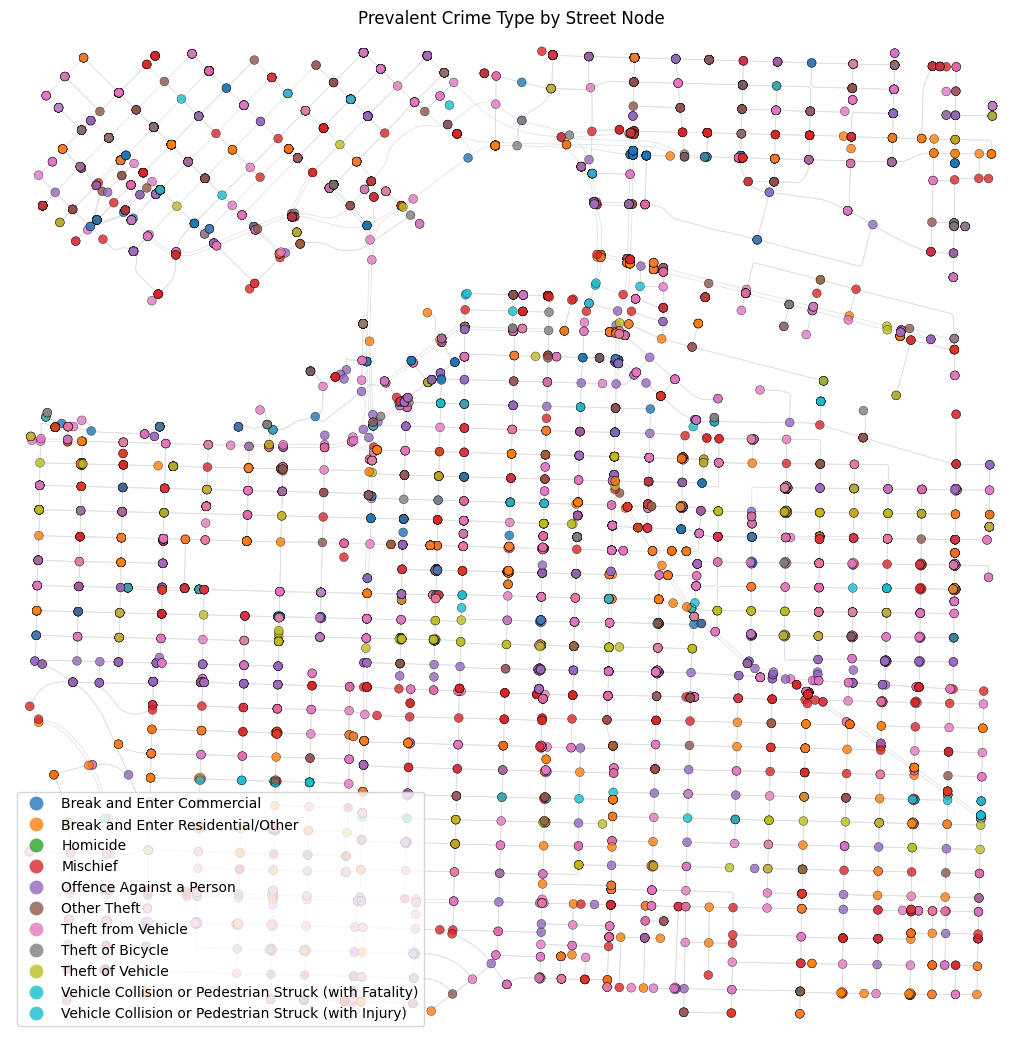

In [19]:
crime_columns = X_matrix_df.columns.tolist()
# Checking
existing_crime_cols = [col for col in crime_columns if col in X_matrix_df.columns]
# Filter out ones with no crime
nodes_with_crime_mask = X_matrix_df[existing_crime_cols].sum(axis=1) > 0
X_matrix_filtered = X_matrix_df[nodes_with_crime_mask].copy()

X_matrix_filtered['Prevalent_Crime'] = X_matrix_filtered[existing_crime_cols].idxmax(axis=1)

nodes_gdf = ox.graph_to_gdfs(G, edges=False)
nodes_visual = gpd.sjoin_nearest(nodes_gdf, gdf_crime, how="inner", distance_col="dist")

fig, ax = plt.subplots(figsize=(13, 13))
ox.plot_graph(G, ax=ax, node_size=0, edge_color='#dddddd', edge_linewidth=0.5, show=False, close=False)
# Plot the color-coded nodes
nodes_visual.plot(column='TYPE', 
                    cmap='tab10', # A qualitative colormap for categories
                    markersize=40, 
                    legend=True, 
                    ax=ax, 
                    alpha=0.8, 
                    edgecolor='k', linewidth=0.3)

ax.set_title("Prevalent Crime Type by Street Node")
ax.axis('off')
plt.show()

# Page Rank Algorithm for Murder Clustering - Chicago

Import dataset and use K-Nearest-Neighbors algorithm to create adjacency matrix

In [20]:
# Read in murder dataset
df = pd.read_csv("ChicagoCrimeData.csv")
coords = df[['latitude', 'longitude']].values

# Using KNN
A_sparse = kneighbors_graph(coords, n_neighbors=10, mode='connectivity', include_self=False)
# Convert
G_crime = nx.from_scipy_sparse_array(A_sparse)

Running Page Rank algorithm with damping factor \alpha = 0.85 (standard)

In [21]:
pagerank_scores = nx.pagerank(G_crime, alpha=0.85)

# Map scores back to original data frame
df['pagerank'] = df.index.map(pagerank_scores)

# Convert to GeoDataFrame for manipulation
gdf_crime = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df.longitude, df.latitude), crs="EPSG:4326")

Plotting

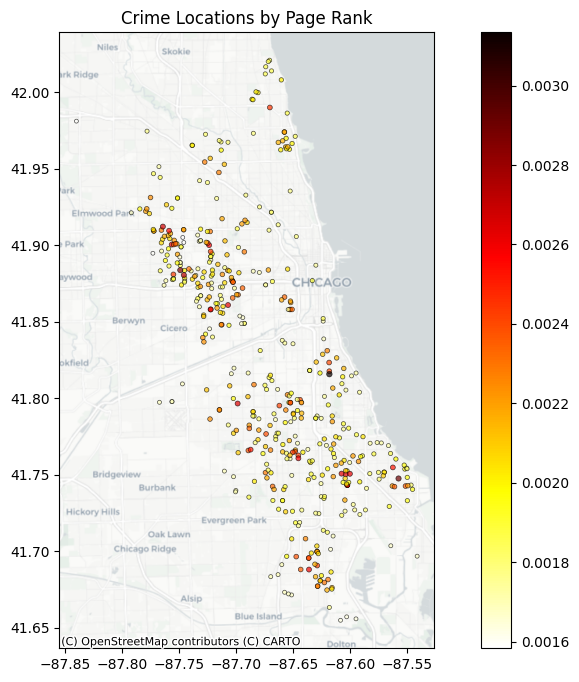

In [22]:
fig, ax = plt.subplots(figsize=(12, 8))

gdf_crime.plot(column='pagerank', 
               cmap='hot_r', 
               markersize=gdf_crime['pagerank'] * 5000,
               alpha=0.7, 
               edgecolor='k', 
               linewidth=0.5,
               legend=True, 
               ax=ax)

ctx.add_basemap(ax, crs=gdf_crime.crs.to_string(), source=ctx.providers.CartoDB.Positron)

ax.set_title("Crime Locations by Page Rank")
plt.show()